# Task 1 - Titanic Survival Prediction

### Objective
To build a machine learning model that predicts whether a passenger survived the Titanic disaster based on passenger information.

In [16]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Titanic dataset

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Understanding the Dataset

The dataset contains information about Titanic passengers.
We will examine the data and identify the important features required for prediction.

In [17]:
# Display basic information about the dataset

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          6

## 2. Data Preprocessing

Data preprocessing is performed to handle missing values and convert categorical information into numerical form.

In [18]:
# Select useful columns

data = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()

# Fill missing age values with median
data['Age'] = data['Age'].fillna(data['Age'].median())

# Convert Sex into numerical values
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

print("Missing values after preprocessing:")
print(data.isnull().sum())

data.head()

Missing values after preprocessing:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500


## 3. Data Visualization

Visualization helps us understand the relationship between passenger characteristics and survival.

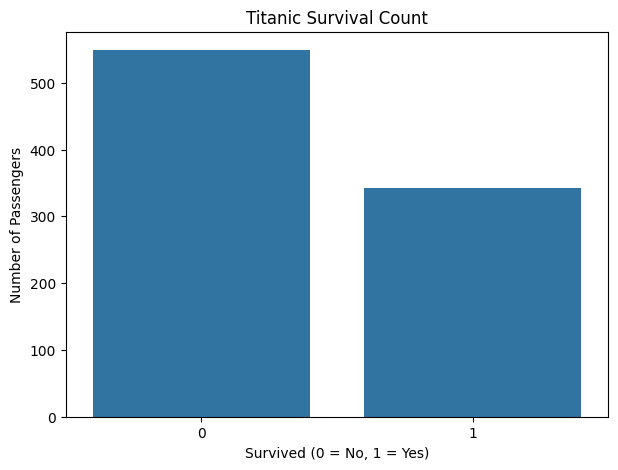

In [6]:
# Survival count visualization

plt.figure(figsize=(7,5))

sns.countplot(x='Survived', data=data)

plt.title('Titanic Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

plt.show()

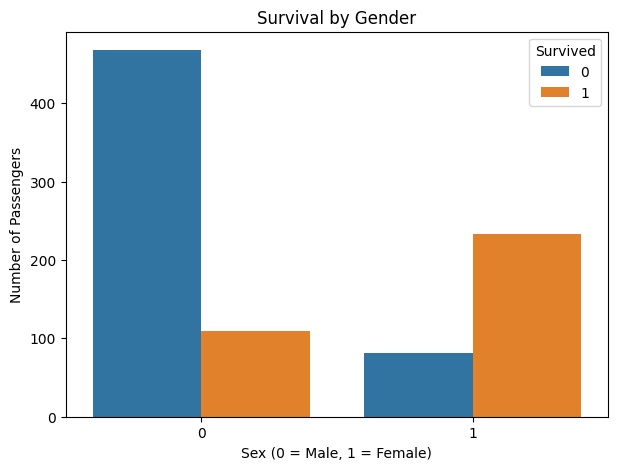

In [25]:
# Survival by gender

plt.figure(figsize=(7,5))

sns.countplot(x='Sex', hue='Survived', data=data)

plt.title('Survival by Gender')
plt.xlabel('Sex (0 = Male, 1 = Female)')
plt.ylabel('Number of Passengers')

plt.show()

## 4. Preparing Data for Machine Learning

The target variable is Survived.
The remaining selected columns are used as input features.


In [19]:
# Define features and target

X = data.drop('Survived', axis=1)
y = data['Survived']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Pclass  Sex   Age  SibSp  Parch     Fare
0       3    0  22.0      1      0   7.2500
1       1    1  38.0      1      0  71.2833
2       3    1  26.0      0      0   7.9250
3       1    1  35.0      1      0  53.1000
4       3    0  35.0      0      0   8.0500

Target:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [20]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 6)
Testing data: (179, 6)


## 5. Machine Learning Model

A Random Forest Classifier is used to predict whether a passenger survived or not.

In [21]:
# Create and train Random Forest model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [22]:
# Make predictions

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0]


## 6. Model Evaluation

The model performance is evaluated using accuracy, classification report and confusion matrix.

In [23]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 80.45 %

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



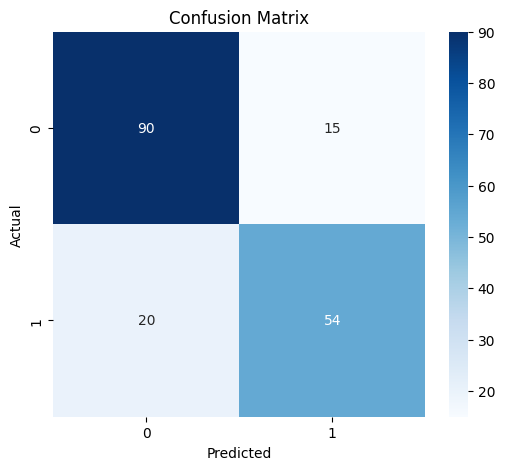

In [24]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 7. Feature Importance

Feature importance shows which passenger characteristics contributed most to the model's predictions.

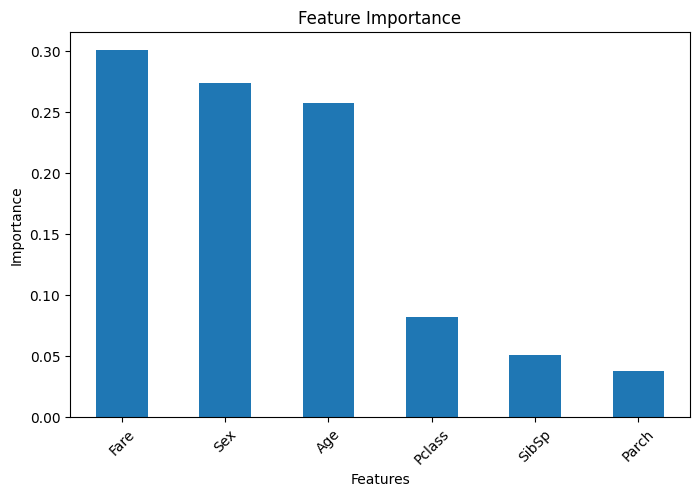

In [14]:
# Feature importance

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

importance.plot(kind='bar')

plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')

plt.xticks(rotation=45)

plt.show()

## 8. Conclusion

The Titanic Survival Prediction project was successfully completed using Python and machine learning.

The dataset was cleaned and preprocessed before training the machine learning model.

A Random Forest Classifier was used to predict passenger survival.

The model was evaluated using accuracy, classification report and confusion matrix.

This project demonstrates the basic Data Science workflow including data collection, data preprocessing, data visualization, machine learning model training and model evaluation.